In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

1 Загрузите таблицу данных (datasets) NMES1988 с сайта:

In [4]:
data = pd.read_csv('./NMES1988.csv')

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4406 entries, 0 to 4405
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   rownames   4406 non-null   int64  
 1   visits     4406 non-null   int64  
 2   nvisits    4406 non-null   int64  
 3   ovisits    4406 non-null   int64  
 4   novisits   4406 non-null   int64  
 5   emergency  4406 non-null   int64  
 6   hospital   4406 non-null   int64  
 7   health     4406 non-null   str    
 8   chronic    4406 non-null   int64  
 9   adl        4406 non-null   str    
 10  region     4406 non-null   str    
 11  age        4406 non-null   float64
 12  afam       4406 non-null   str    
 13  gender     4406 non-null   str    
 14  married    4406 non-null   str    
 15  school     4406 non-null   int64  
 16  income     4406 non-null   float64
 17  employed   4406 non-null   str    
 18  insurance  4406 non-null   str    
 19  medicaid   4406 non-null   str    
dtypes: float64(2), int6

2 Проверьте количественные показатели на принадлежность к нормальному закону распределения (scipy.stats.shapiro).

Количественные:
visits, chronic, age, school, income

In [6]:
columns = ["visits", "chronic", "age", "school", "income"]
for col in columns:
    a = data[col].dropna()
    res = stats.shapiro(a)
    print(f"{col}: W={res.statistic}, p-value={res.pvalue}")


visits: W=0.7259005904336103, p-value=5.712918098127624e-65
chronic: W=0.8762279682108794, p-value=1.580199454928586e-50
age: W=0.9307003546802189, p-value=3.6018224955923593e-41
school: W=0.9595015045420544, p-value=2.1782425422411338e-33
income: W=0.6050408850085911, p-value=3.126304463470573e-72


Все пять количественных ненормального распределения,  так как p value < 0.05

3 Рассчитайте значение коэффициента корреляции Спирмена для показателей visits и age (scipy.stats.spearmanr).

In [18]:
correlation, p_value = stats.spearmanr(data['visits'], data['age'])
print(f"Коэффициент корреляции Спирмена: {correlation}")
print(f"P-value: {p_value}")

Коэффициент корреляции Спирмена: 0.053405979341972006
P-value: 0.0003903972162387243


p-value < 0.05, кореляция статистически значема, но почти не прослеживается, так как коэффициент очень близок к нулю

4 Постройте матрицу корреляции для количественных показателей (cor{stats}) Отобразите ее графически (pandas.DataFrame.corr).

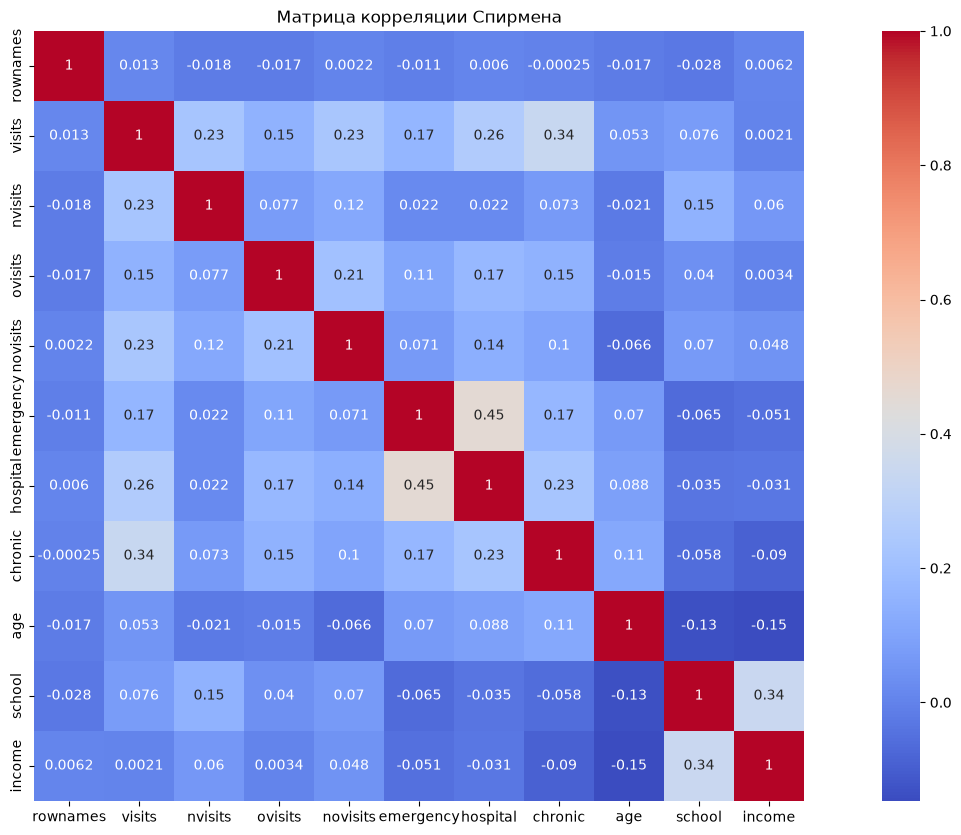

In [16]:
corr_matrix = data.select_dtypes(include=['number']).corr(method='spearman')
plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Матрица корреляции Спирмена')
plt.show()

5 Определите степень зависимости переменной visits с другими количественными показателями с помощью коэффициентов корреляции. Проверьте значимость коэффициентов корреляции, значения которых меньше 0.5 (scipy.stats.spearmanr). Проведите анализ для всей совокупности данных и отдельно для мужчин и женщин. Сравните полученные результаты.

In [19]:
for col in columns:
        rho, p = stats.spearmanr(data['visits'], data[col])
        print(f"visits vs {col}: rho = {rho}, p-value = {p}")

visits vs visits: rho = 1.0, p-value = 0.0
visits vs chronic: rho = 0.3375485578654738, p-value = 7.34100692259753e-118
visits vs age: rho = 0.053405979341972006, p-value = 0.0003903972162387243
visits vs school: rho = 0.0758939397371122, p-value = 4.570659921236238e-07
visits vs income: rho = 0.00212881620085251, p-value = 0.8876598051214755


In [20]:
for col in columns:
        rho, p = stats.spearmanr(data[data['gender'] == 'male']['visits'], data[data['gender'] == 'male'][col])
        print(f"visits vs {col}: rho = {rho}, p-value = {p}")

visits vs visits: rho = 0.9999999999999999, p-value = 0.0
visits vs chronic: rho = 0.3335756307453127, p-value = 1.8133420889137157e-47
visits vs age: rho = 0.06417396407285146, p-value = 0.0067921175557457214
visits vs school: rho = 0.1326710462265813, p-value = 1.9638497403908872e-08
visits vs income: rho = 0.09956792594793024, p-value = 2.6002557632865908e-05


In [22]:
for col in columns:
        rho, p = stats.spearmanr(data[data['gender'] == 'female']['visits'], data[data['gender'] == 'female'][col])
        print(f"visits vs {col}: rho = {rho}, p-value = {p}")

visits vs visits: rho = 1.0, p-value = 0.0
visits vs chronic: rho = 0.3397479297205892, p-value = 5.249169669837001e-72
visits vs age: rho = 0.03964522145409831, p-value = 0.042132852494261415
visits vs school: rho = 0.03674356430895175, p-value = 0.05965122909541226
visits vs income: rho = -0.036779445279392246, p-value = 0.0594024208065215


Вывод:
Больше всего на значение влияет chronic - чем их больше, тем больше посещений, p-value < 0.05 - статистически значемая

От income почти не зависит. p value >= 0.05 - cтатистически не значима

school - у мужчин p-value < 0.05 есть кореляция, в отличие от статистически не значимой у женщин p value >= 0.05 ,

age - у обоих gender статистически значимая, но корреляция мала

6 Постройте матрицы сопряженности по показателям gender и health, gender и chronic, gender и employed.

In [23]:
table_health = pd.crosstab(data["gender"], data["health"])
table_chronic = pd.crosstab(data["gender"], data["chronic"])
table_employed = pd.crosstab(data["gender"], data["employed"])

In [26]:
print(table_health)

health  average  excellent  poor
gender                          
female     2093        193   342
male       1416        150   212


In [27]:
print(table_chronic)

chronic    0    1    2    3    4   5   6  7  8
gender                                        
female   568  934  598  296  134  74  17  6  1
male     457  564  370  229   86  53  17  0  2


In [28]:
print(table_employed)

employed    no  yes
gender             
female    2435  193
male      1516  262


7 Преобразуйте факторные показатели в факторы.

In [29]:
data['health'] = pd.Categorical(
    data['health'],
    categories=['poor', 'average', 'excellent'],
    ordered=False
)

data['adl'] = pd.Categorical(
    data['adl'],
    categories=['limited', 'normal'],
    ordered=False
)

data['region'] = pd.Categorical(
    data['region'],
    categories=['northeast', 'midwest', 'west', 'other'],
    ordered=False
)

data['gender'] = pd.Categorical(
    data['gender'],
    categories=['female', 'male'],
    ordered=False
)

data['married'] = pd.Categorical(
    data['married'],
    categories=['no', 'yes'],
    ordered=False
)

data['employed'] = pd.Categorical(
    data['employed'],
    categories=['no', 'yes'],
    ordered=False
)

data['insurance'] = pd.Categorical(
    data['insurance'],
    categories=['no', 'yes'],
    ordered=False
)

In [30]:
print(data.dtypes)

rownames        int64
visits          int64
nvisits         int64
ovisits         int64
novisits        int64
emergency       int64
hospital        int64
health       category
chronic         int64
adl          category
region       category
age           float64
afam              str
gender       category
married      category
school          int64
income        float64
employed     category
insurance    category
medicaid          str
dtype: object


8 Определите, есть ли различия показателя visits по категориям факторов gender, married, employed, insurance (scipy.stats.kruskal). Постройте диаграммы размаха (seaborn.boxplot).

In [36]:
factors = ["gender", "married", "employed", "insurance"]


for fuc in factors:
    groups = [
        group["visits"].dropna().values
        for _, group in data.groupby(fuc, observed=True)
    ]

    groups = [g for g in groups if len(g) > 0]

    H, p_value = stats.kruskal(*groups)
    print(f"Kruskal-Wallis test for {fuc}: H={H}, p-value={p_value}")



Kruskal-Wallis test for gender: H=20.45511285091891, p-value=6.104625715642246e-06
Kruskal-Wallis test for married: H=0.1268698958053563, p-value=0.7216997733460649
Kruskal-Wallis test for employed: H=9.554659195672603, p-value=0.001994425382261192
Kruskal-Wallis test for insurance: H=50.79266632934914, p-value=1.026565651004096e-12


Зависимости у married по visits практически нет. p > 0.05 - статистически не значимо.

У employed, gender и insurance влияние есть, слабое, среднее и сильное соответственно. У всех троих p value < 0.05, значит с visits у каждой есть реальные статистические различия

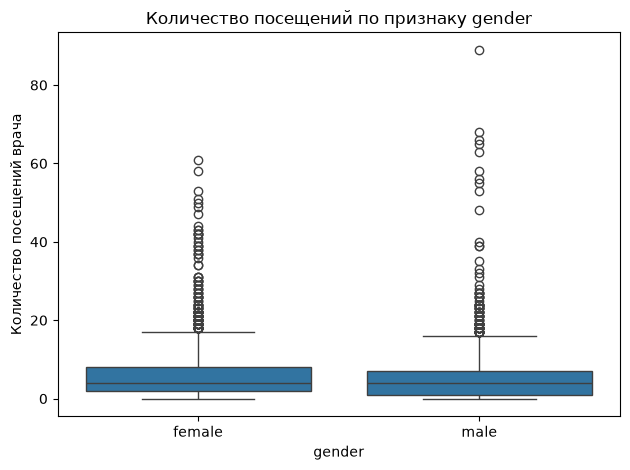

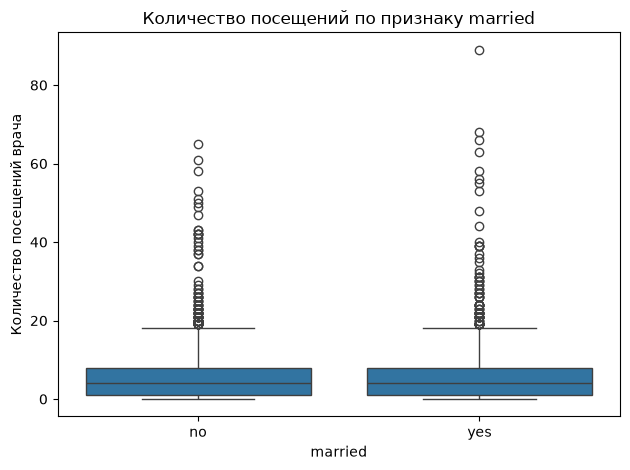

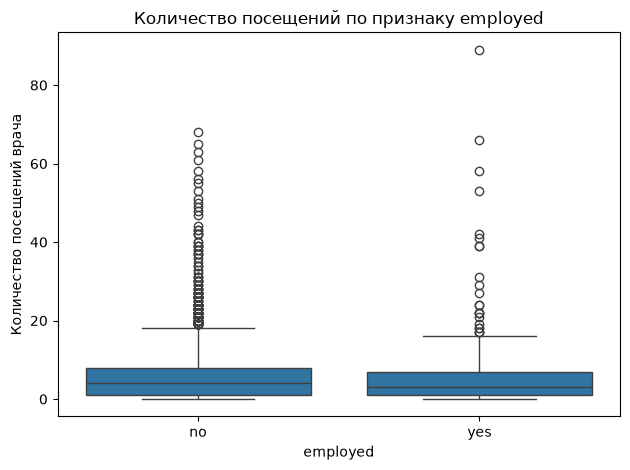

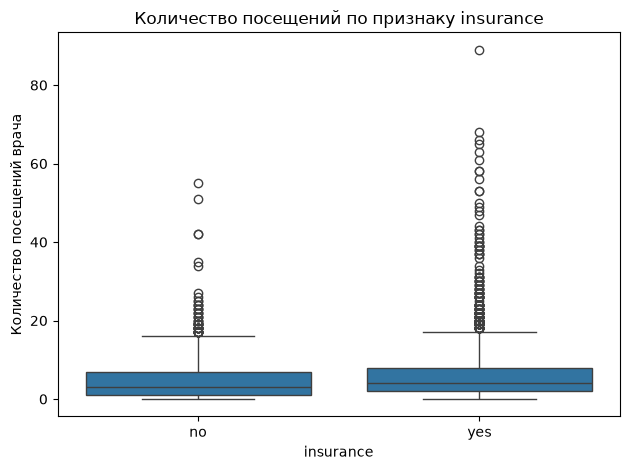

In [45]:
for col in factors:
    sns.boxplot(data=data, x=col, y="visits")
    plt.title(f"Количество посещений по признаку {col}")
    plt.xlabel(col)
    plt.ylabel("Количество посещений врача")
    plt.tight_layout()
    plt.show()


9 Определите, есть ли различия показателя income по категориям факторов gender, married, region, employed. Отобразите различие с помощью столбиковых диаграмм (seaborn.barplot).

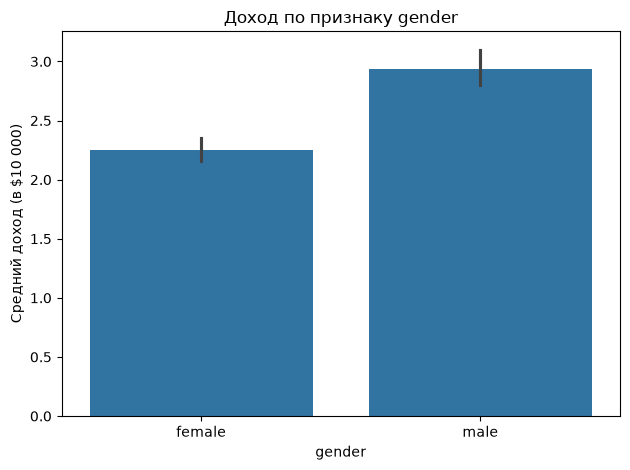

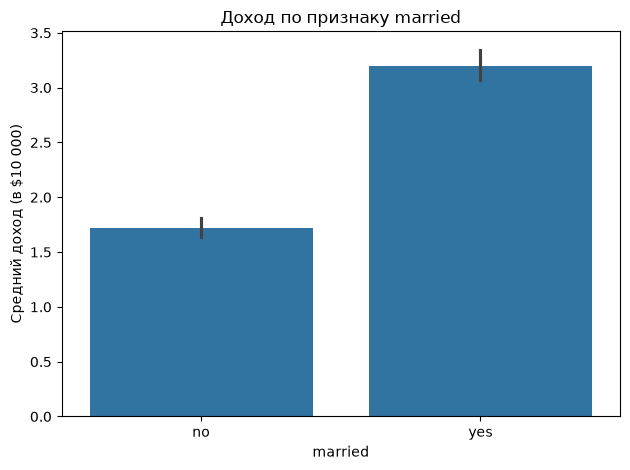

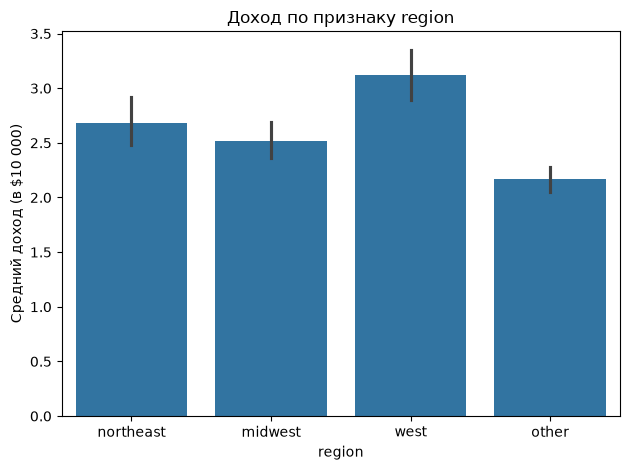

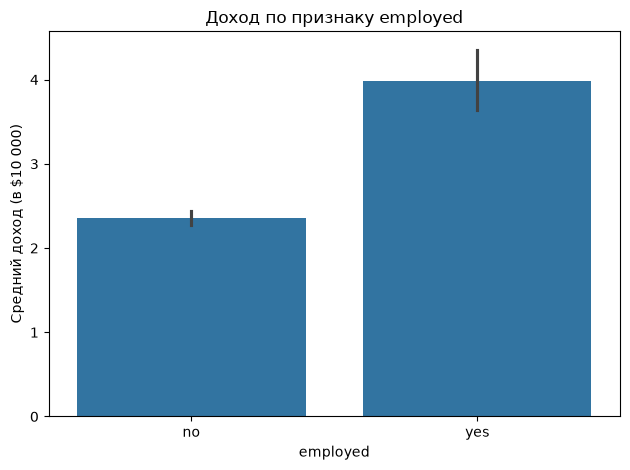

In [43]:
factors_income = ["gender", "married", "region", "employed"]


for col in factors_income:
    
    sns.barplot(data=data, x=col, y="income")
    
    plt.title(f"Доход по признаку {col}")
    plt.xlabel(col)
    plt.ylabel("Средний доход (в $10 000)")
    
    plt.tight_layout()
    plt.show()


Различия есть. Они хорошо прослеживаются на столбиковых жиаграм. Самый большой доход у трудоустроенных женатых мужчин с запада.